## Network Intrusion Detection Using a Transformer Autoencoder
### Principles of AI - Machine Learning Assignment

In [1]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

---

#### Getting the Dataset

In [3]:
# !kaggle datasets list -s NSL-KDD
# !kaggle datasets list -s hassan06/nslkdd
!kaggle datasets download -d hassan06/nslkdd

Dataset URL: https://www.kaggle.com/datasets/hassan06/nslkdd
License(s): unknown




  0%|          | 0.00/13.9M [00:00<?, ?B/s]
  7%|▋         | 1.00M/13.9M [00:00<00:09, 1.43MB/s]
 14%|█▍        | 2.00M/13.9M [00:00<00:04, 2.90MB/s]
 29%|██▉       | 4.00M/13.9M [00:01<00:01, 5.21MB/s]
 51%|█████     | 7.00M/13.9M [00:01<00:00, 9.21MB/s]
 65%|██████▍   | 9.00M/13.9M [00:01<00:00, 11.3MB/s]
 79%|███████▉  | 11.0M/13.9M [00:01<00:00, 13.0MB/s]
100%|██████████| 13.9M/13.9M [00:01<00:00, 15.4MB/s]
100%|██████████| 13.9M/13.9M [00:01<00:00, 9.33MB/s]


---

#### Exploratory Analysis

In [2]:
train_path = 'nsl-kdd/KDDTrain+.txt'
train_file = pd.read_csv(train_path, header=None)

In [3]:
print('Shape:', train_file.shape)
print("\nFirst 5 rows (head):")
print(train_file.head())

Shape: (125973, 43)

First 5 rows (head):
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


In [4]:
print("Info:")
print(train_file.info())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21  

In [5]:
print("Missing values per column:")
print(train_file.isna().sum())

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
dtype: int64


In [6]:
cols = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

train_file.columns = cols

##### Class Distribution
Imbalanced, but realistic for network traffic

**Distribution:**
- Normal:               67,343
- Frequent (> 1000):    ~ 55,000
- Medium (100 - 1000):  ~ 5,000
- Rare (< 100):         ~ 167
- Very Rare (< 10):     ~ 50

**Dominant Attack Types:**
- neptune  :    41,214      - massive DoS attack
- satan    :    3633        - scanning / probing
- ipsweep  :    3599        - network sweep
- portsweep:    2931
- smurf    :    2646
- nmap     :    1493

**Very Rare Attack Types:**
- loadmodule:   9
- ftp_write :   8
- multihop  :   7
- phf       :   4
- perl      :   3
- spy       :   2

In [7]:
label_counts = train_file['label'].value_counts()
print(label_counts)

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


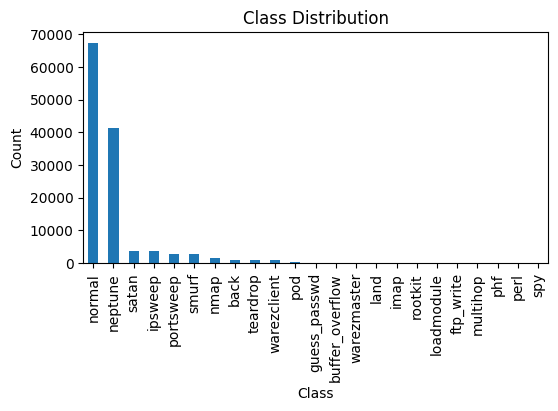

In [8]:
plt.figure(figsize = (6, 3))
label_counts.plot(kind = 'bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

##### Numerical Feature Distribution

- Normal behavior: small packets, quick connections $\Rightarrow$ most numeric features are skewed $\Rightarrow$ needs scaling
- Attacks often create big bursts or unusual sequences $\Rightarrow$ anomalies stick out dramatically
- `srv_count` & `count` peaks:
    - very low values = normal traffic
    - medium values = scanning / probing
    - high values = heavy DoS attacks

In [9]:
numeric_cols = train_file.select_dtypes(include = np.number).columns
key_features = [ 'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count' ]
train_file[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


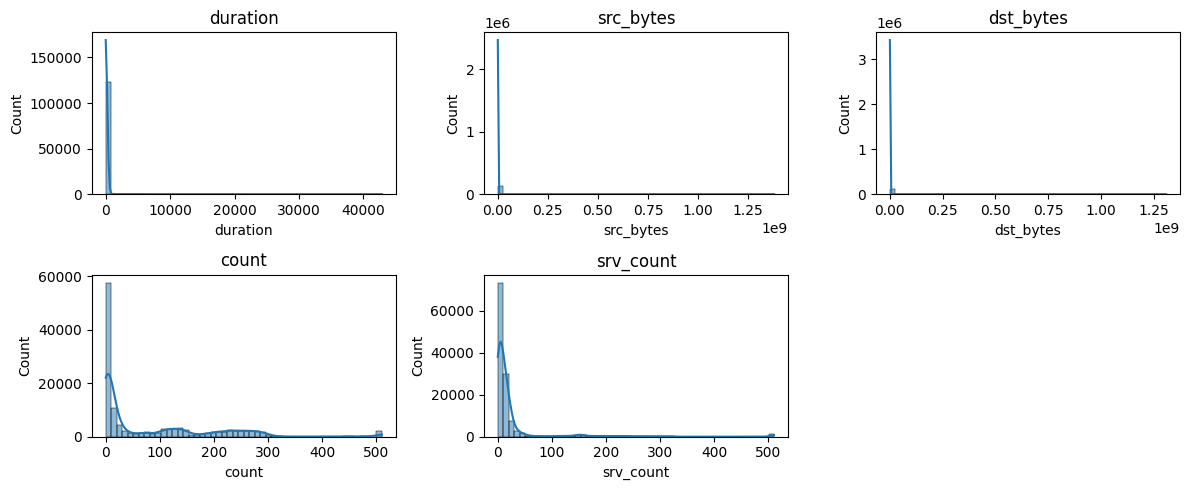

In [10]:
plt.figure(figsize = (12, 5))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_file[col], bins = 50, kde = True)
    plt.title(col)

plt.tight_layout()
plt.show()

##### Correlation Matrix

**Connection-Level Error Rates:**
- `serror_rate` $\leftrightarrow$ `srv_error_rate` $\leftrightarrow$ `dst_host_serror_rate` $\leftrightarrow$ `dst_host_srv_serror_rate`
- closely related $\Rightarrow$ redundancy
- indicators of DoS attacks $\Leftarrow$ often generate many failed connections

**Response Error Rates:**
- `rerror_rate` $\leftrightarrow$ `srv_rerror_rate` $\leftrightarrow$ `dst_host_rerror_rate` $\leftrightarrow$ `dst_host_srv_rerror_rate`
- closely related $\Rightarrow$ redundancy

**Count-Based Features:**
- `count` $\leftrightarrow$ `srv_count` $\leftrightarrow$ `dst_host_count` $\leftrightarrow$ `dst_host_srv_count`
- more faint, but still correlated $\Leftarrow$ DoS attacks / port scans flood connections repetitively

**No correlations:**
- `num_outbound_cmds`
- `difficulty`

**Others:**
- most other features don't correlate strongly $\Rightarrow$ they bring relevant information

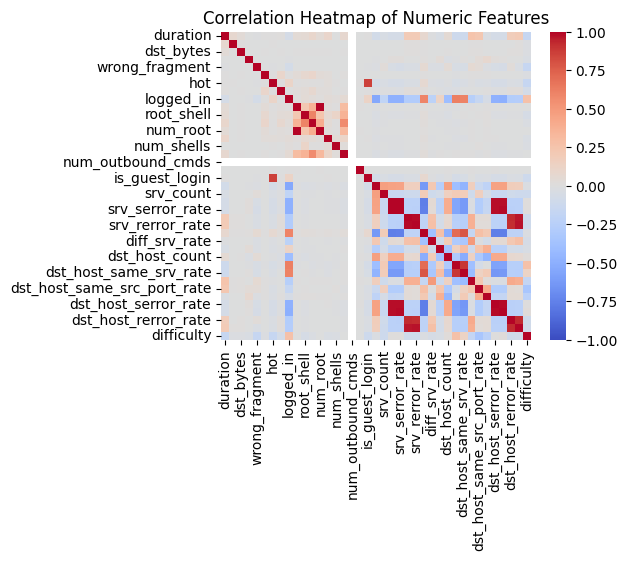

In [11]:
plt.figure(figsize = (5, 4))
correlation = train_file[numeric_cols].corr()

sns.heatmap(correlation, cmap = 'coolwarm', vmax = 1.0, vmin = -1.0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### Dimensionality Reduction

- normal traffic is fairly consistent
- each attack family behaves differently $\Rightarrow$ multiple attack clusters
- some attacks try to mimic normal traffic to blend in $\Rightarrow$ harder to detect

In [12]:
train_file_reduced = train_file.drop(columns = [
    'protocol_type', 'service', 'flag',     # Categorical columns
    'label',
    'difficulty',
    'num_outbound_cmds'
])

In [13]:
scaler = StandardScaler()
train_file_scaled = scaler.fit_transform(train_file_reduced)

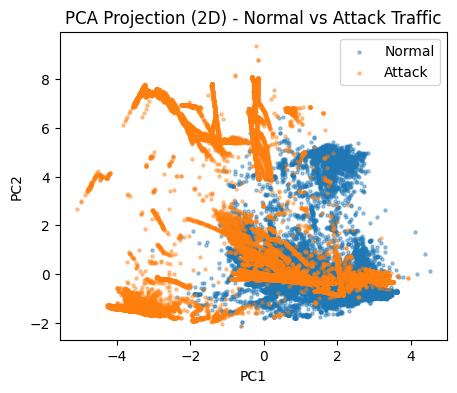

In [14]:
pca = PCA(n_components = 2)
train_file_pca = pca.fit_transform(train_file_scaled)

pca_df = pd.DataFrame(train_file_pca, columns = ['PC1', 'PC2'])
pca_df['label'] = train_file['label']

plt.figure(figsize = (5, 4))

normal_points = pca_df[pca_df['label'] == 'normal']
attack_points = pca_df[pca_df['label'] != 'normal']

plt.scatter(normal_points['PC1'], normal_points['PC2'], s = 5, alpha = 0.4, label = 'Normal')
plt.scatter(attack_points['PC1'], attack_points['PC2'], s = 5, alpha = 0.4, label = 'Attack')

plt.title("PCA Projection (2D) - Normal vs Attack Traffic")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

---

#### Data Preparation

Load train & test files, drop unneeded columns

In [15]:
train = pd.read_csv('nsl-kdd/KDDTrain+.txt', header = None)
test = pd.read_csv('nsl-kdd/KDDTest+.txt', header = None)

train.columns = cols
test.columns = cols

train = train.drop(columns = ['difficulty', 'num_outbound_cmds'])
test = test.drop(columns = ['difficulty', 'num_outbound_cmds'])

Fitting one-hot encoder on training data, then applying same dummy columns to test data & filling missing

In [16]:
train_encoded = pd.get_dummies(train, columns = ['protocol_type', 'service', 'flag'])

test_encoded = pd.get_dummies(test, columns = ['protocol_type', 'service', 'flag'])
test_encoded = test_encoded.reindex(columns = train_encoded.columns, fill_value = 0)

Separating labels from features:

In [17]:
x_train = train_encoded.drop(columns = ['label'])
y_train = (train_encoded['label'] != 'normal').astype(int)
x_test = test_encoded.drop(columns = ['label'])
y_test = (test_encoded['label'] != 'normal').astype(int)

Scaling features using only training data:

In [18]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Preparing normal-only & attack-only sets for anomaly detection:

In [19]:
x_train_normal = x_train_scaled[y_train == 0]
x_test_normal = x_test_scaled[y_test == 0]
x_test_attack = x_test_scaled[y_test == 1]

---

#### Transformer Autoencoder

In [20]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, feature_dim, dim_model = 128, num_heads = 8, num_layers = 3, dim_ff = 256):
        super().__init__()

        self.feature_dim = feature_dim
        self.dim_model = dim_model

        # Linearly embedding each scalar feature into dim_model dimension
        self.embedding = nn.Linear(1, dim_model)

        # Positional encoding
        self.pos_embedding = nn.Parameter(torch.randn(1, feature_dim, dim_model))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = dim_model,
            nhead = num_heads,
            dim_feedforward = dim_ff,
            batch_first = True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model = dim_model,
            nhead = num_heads,
            dim_feedforward = dim_ff,
            batch_first = True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        # Final projection back to scalar features
        self.output_layer = nn.Linear(dim_model, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embedding(x) + self.pos_embedding
        
        memory = self.encoder(x)
        decoded = self.decoder(x, memory)

        out = self.output_layer(decoded).squeeze(-1)
        return out

##### Training

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerAutoencoder(feature_dim = x_train_normal.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

x = torch.tensor(x_train_normal, dtype = torch.float32).to(device)
loader = torch.utils.data.DataLoader(x, batch_size = 128, shuffle = True)

patience = 10
losses = []
min_loss = float('inf')
since_last_improve = 0

model.train()
for epoch in range(30):
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        reconstruction = model(batch)

        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    total_loss /= len(loader)
    losses.append(total_loss)

    if (total_loss < min_loss):
        min_loss = total_loss
        since_last_improve = 0

        torch.save(model.state_dict(), 'best_model.pt')
    else:
        since_last_improve += 1

    # Early stop
    if since_last_improve >= patience:
        print(f"Early stop at epoch {epoch + 1}!")
        break

    print(f"Epoch {epoch + 1}:\tLoss = {total_loss:.6f}")

print("Model saved at it's best in best_model.pt!")

Epoch 1:	Loss = 0.315046
Epoch 2:	Loss = 0.168996
Epoch 3:	Loss = 0.113302
Epoch 4:	Loss = 0.092584
Epoch 5:	Loss = 0.071491
Epoch 6:	Loss = 0.065727
Epoch 7:	Loss = 0.092398
Epoch 8:	Loss = 0.062296
Epoch 9:	Loss = 0.056900
Epoch 10:	Loss = 0.064988
Epoch 11:	Loss = 0.042875
Epoch 12:	Loss = 0.051215
Epoch 13:	Loss = 0.052612
Epoch 14:	Loss = 0.040392
Epoch 15:	Loss = 0.032370
Epoch 16:	Loss = 0.094234
Epoch 17:	Loss = 0.073145
Epoch 18:	Loss = 0.041121
Epoch 19:	Loss = 0.169120
Epoch 20:	Loss = 0.539664
Epoch 21:	Loss = 0.307545
Epoch 22:	Loss = 0.239603
Epoch 23:	Loss = 0.165223
Epoch 24:	Loss = 0.185257
Early stop at epoch 25!
Model saved at it's best in best_model.pt!


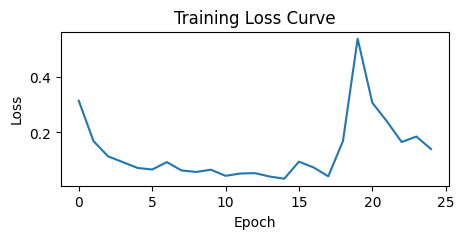

In [34]:
plt.figure(figsize = (5, 2))
plt.plot(losses, label = "Training Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training Loss Curve")
plt.show()

##### Inference

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerAutoencoder(feature_dim = x_train_normal.shape[1]).to(device)
model.load_state_dict(torch.load('best_model.pt', map_location = device))
model.eval()

test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32)
test_loader = torch.utils.data.DataLoader(test_tensor, batch_size = 256, shuffle = False)

all_reconstruction_cpu = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        reconstruction = model(batch)

        all_reconstruction_cpu.append(reconstruction.cpu())

        del batch, reconstruction
        torch.cuda.empty_cache()

reconstruction_cpu = torch.cat(all_reconstruction_cpu, dim = 0).numpy()
x_test_cpu = x_test_scaled
features_errors = (reconstruction_cpu - x_test_cpu) ** 2
errors = features_errors.mean(axis = 1)

threshold = np.percentile(errors, 95)
y_pred = (errors > threshold).astype(int)

In [24]:
idx_normal = np.where(y_test == 0)[0][0]    # First normal sample
idx_attack = np.where(y_test == 1)[0][0]    # First attack sample
idx_worst = np.argmax(errors)               # Worst reconstruction

Plotting reconstruction:

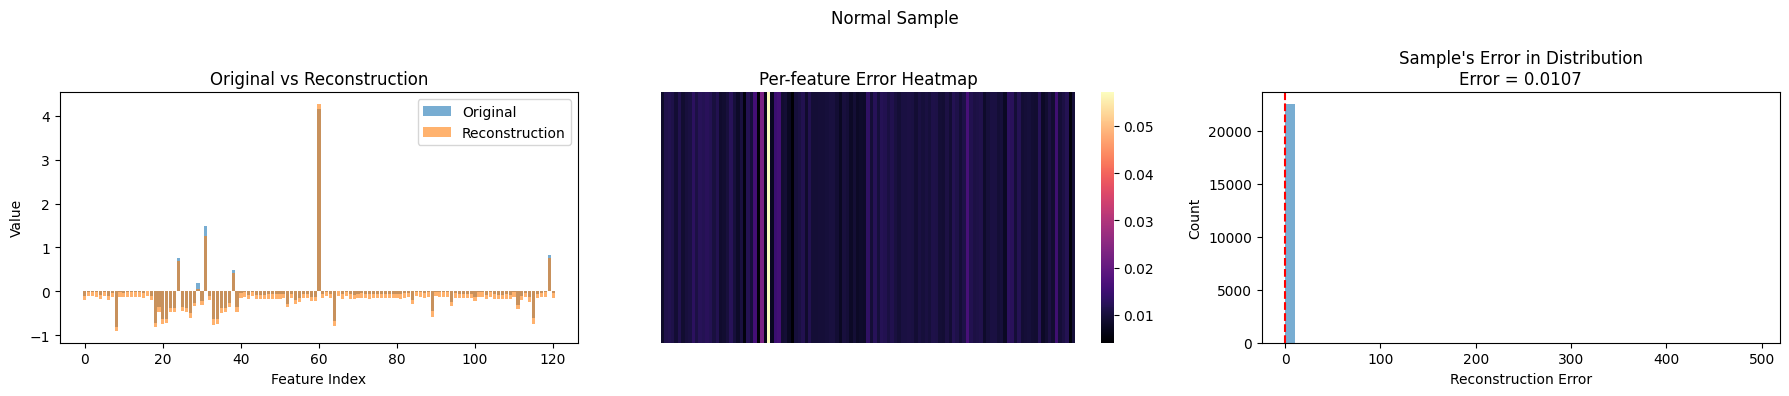

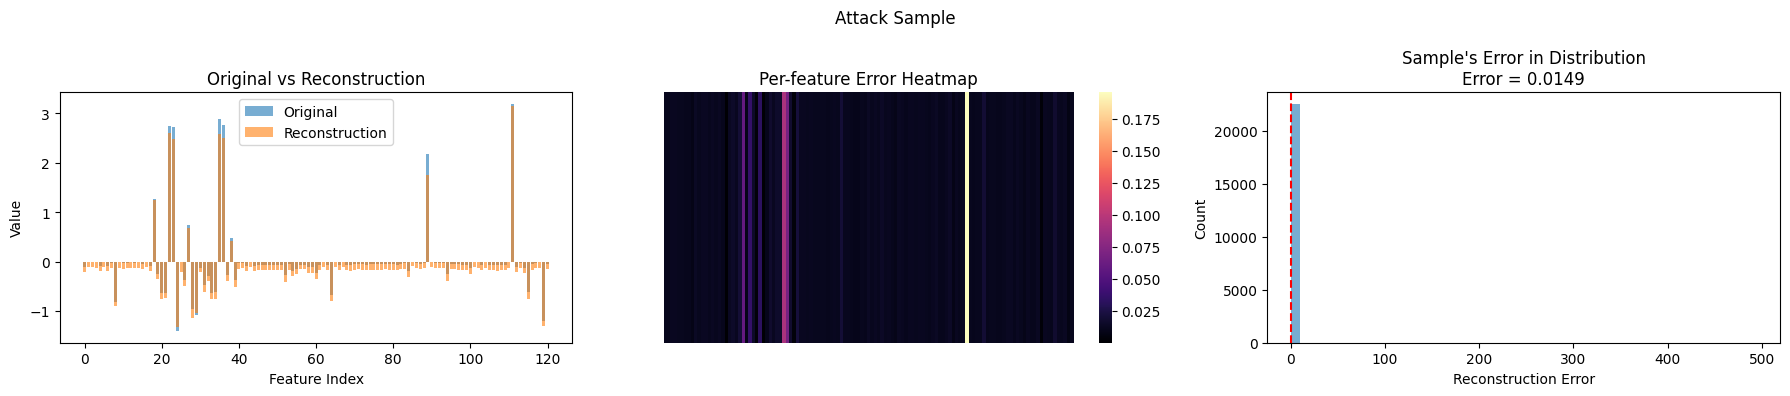

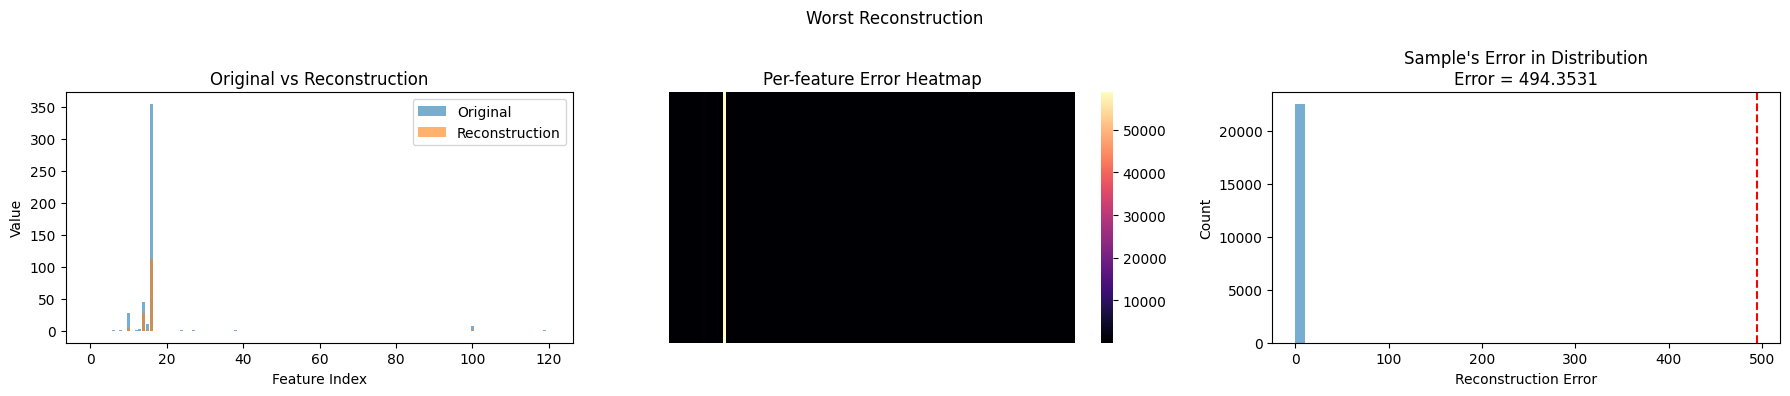

In [29]:
def visualize_sample(index, title):
    original = x_test_cpu[index]
    reconstruction = reconstruction_cpu[index]
    errors_feat = features_errors[index]

    fig, axes = plt.subplots(1, 3, figsize = (18, 4))

    fig.suptitle(title)

    # Original vs Reconstruction
    axes[0].bar(range(len(original)), original, alpha = 0.6, label = 'Original')
    axes[0].bar(range(len(reconstruction)), reconstruction, alpha = 0.6, label = 'Reconstruction')
    axes[0].set_title("Original vs Reconstruction")
    axes[0].set_xlabel("Feature Index")
    axes[0].set_ylabel('Value')
    axes[0].legend()

    # Heatmap
    sns.heatmap(
        errors_feat.reshape(1, -1),
        cmap = 'magma',
        cbar = True,
        ax = axes[1],
        xticklabels = False,
        yticklabels = False
    )
    axes[1].set_title("Per-feature Error Heatmap")

    # Error Distribution Highlight
    axes[2].hist(errors, bins = 50, alpha = 0.6)
    axes[2].axvline(errors[index], color = 'red', linestyle = '--')
    axes[2].set_title(f"Sample's Error in Distribution\nError = {errors[index]:.4f}")
    axes[2].set_xlabel("Reconstruction Error")
    axes[2].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

visualize_sample(idx_normal, "Normal Sample")
visualize_sample(idx_attack, "Attack Sample")
visualize_sample(idx_worst, "Worst Reconstruction")